In [3]:
import pandas as pd
data = pd.read_csv("titanic.csv")


In [4]:
# Sex转换为0和1
data.Sex = data.Sex.map({'female':0, 'male':1})

# Embarked独热编码
embarked_d = pd.get_dummies(data.Embarked, prefix='Embarked', drop_first=True)
data = pd.concat([data, embarked_d], axis=1)


In [5]:
feature_cols = ['Pclass', 'Sex', 'Age', 'Embarked_Q', 'Embarked_S']
X = data[feature_cols]
y = data.Survived


In [8]:
from sklearn.tree import DecisionTreeClassifier
treeclf = DecisionTreeClassifier(max_depth=3, random_state=1)
treeclf.fit(X, y)


DecisionTreeClassifier(max_depth=3, random_state=1)

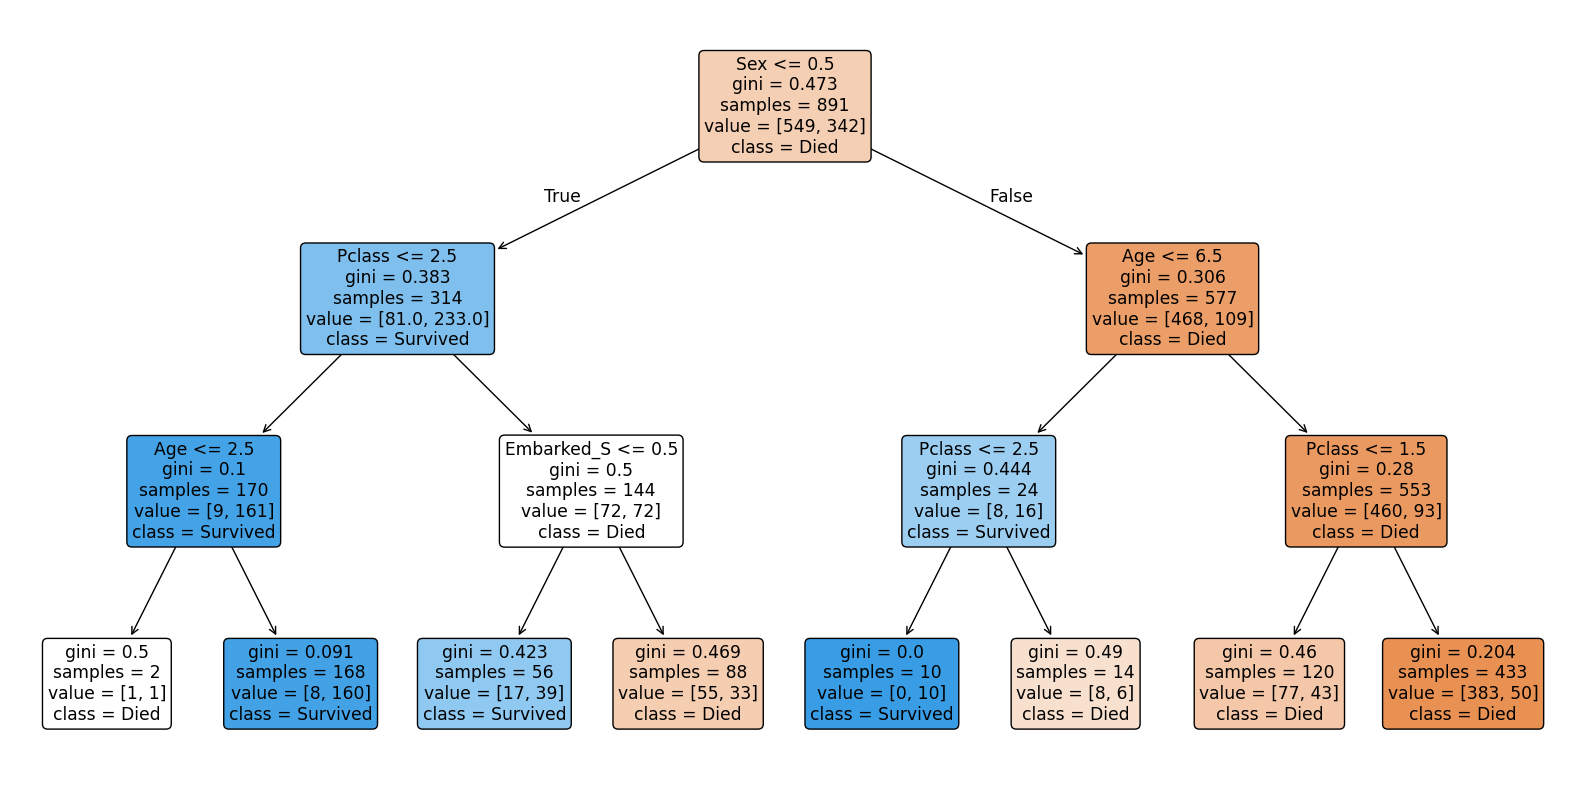

In [11]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(20,10))
tree.plot_tree(treeclf, 
               feature_names=feature_cols, 
               class_names=["Died", "Survived"],  # 注意这里改成两个类别
               filled=True, 
               rounded=True)
plt.show()


In [10]:
pd.DataFrame({'feature':feature_cols, 'importance':treeclf.feature_importances_})


,feature,importance
0,Pclass,0.242664
1,Sex,0.655584
2,Age,0.064494
3,Embarked_Q,0.000000
4,Embarked_S,0.037258
